# Dynamics and Predictive Power of the Variance Risk Premium in S&P500 Options
## Part 2 - Estimation and Analysis of model 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 
import pickle

from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table
from utilities.fixed_random_effects import within_estimator, build_surface_panel


In [2]:
# ── Pour recharger dans un autre notebook ─────────────────────────────────────
with open('time_series.pkl', 'rb') as f:
    ts = pickle.load(f)
reg_overlap    = ts['reg_overlap']
reg_nonoverlap = ts['reg_nonoverlap']
metrics        = ts['metrics']
df             = ts['df']
spot_ts         = ts['spot_ts']

In [3]:
reg_nonoverlap

,atm_iv,skew,convexity,iv_put_wing,iv_call_wing,rv_past,rv_forward,vrp
date,,,,,,,,
2017-07-10,0.108259,NaN,NaN,0.170180,NaN,0.072598,0.030226,0.035661
2017-08-08,0.090486,0.075884,0.057998,0.186426,0.110542,0.030226,0.099108,0.060261
2017-09-07,0.092585,0.111919,0.074147,0.222692,0.110773,0.099108,0.047533,-0.006523
2017-10-06,0.090122,NaN,NaN,0.182154,NaN,0.047533,0.039436,0.042589
2017-11-06,0.103325,0.057738,0.026979,0.159173,0.101435,0.039436,0.066819,0.063889
2017-12-06,0.119754,0.095963,0.027677,0.195412,0.099450,0.066819,0.064294,0.052935
2018-01-08,0.124273,0.056143,0.012391,0.164736,0.108593,0.064294,0.267340,0.059979
2018-02-07,0.211443,0.159899,0.041709,0.333101,0.173202,0.267340,0.192476,-0.055898
2018-03-09,0.117573,0.056525,0.042073,0.187909,0.131383,0.192476,0.229375,-0.074903


In [4]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


## 1 · Regression analysis

We implement OLS from scratch:

$$\hat\beta = (X'X)^{-1}X'y, \qquad s^2 = \frac{\hat\varepsilon'\hat\varepsilon}{n-k}, \qquad \widehat{\text{Var}}(\hat\beta) = s^2(X'X)^{-1}$$

**Dependent variable** $y_t = RV^{\text{fwd}}_t$: annualized realized volatility over the
21 trading days following day $t$:

$$RV^{\text{fwd}}_t = \sqrt{252}\cdot\hat\sigma(r_{t+1},\ldots,r_{t+21})$$

**Regressors**: ATM IV at constant 30-day maturity (VIX methodology), skew, convexity.

We estimate four nested models: M1 ⊂ M2 ⊂ M3, then M4 as the parsimonious specification.

In [5]:
# ── Import VIX ─────────────────────────────────────────────────────────────────
vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end="2018-06-08")
Vix_close = hist["Close"]
Vix_close.index = Vix_close.index.tz_localize(None)

# ── Overlapping ────────────────────────────────────────────────────────────────
reg = reg_overlap.copy()
reg = reg.join(Vix_close.rename("vix"), how="left")
reg['vix_norm']       = reg['vix'] / 100
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# ── Non-overlapping ────────────────────────────────────────────────────────────
reg_no = reg_nonoverlap.copy()
reg_no = reg_no.join(Vix_close.rename("vix"), how="left")
reg_no['vix_norm']       = reg_no['vix'] / 100
reg_no['vix_atm_spread'] = reg_no['vix_norm'] - reg_no['atm_iv']

print(f"Overlapping    : N = {len(reg.dropna(subset=['vix']))}")
print(f"Non-overlapping: N = {len(reg_no.dropna(subset=['vix']))}")


Overlapping    : N = 211
Non-overlapping: N = 11


### 1.1 with overlap

In [6]:
y = reg_overlap['rv_forward']

### Model 1 — Mincer-Zarnowitz regression (baseline)

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \varepsilon_t$$

**Interpretation**:
- If $\alpha = 0$ and $\beta_1 = 1$: IV is an **unbiased predictor** of future RV
- In practice: $\beta_1 < 1$ and $\alpha > 0$ → IV **over-estimates** RV on average (= VRP)

In [7]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0112    0.0171    0.658    0.5114 
ATM_IV                    0.8192    0.1266    6.471    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1669
Adj. R²                   0.1629
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 2 — Adding skew

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \varepsilon_t$$


In [8]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0603    0.0213    2.838    0.0051 **
ATM_IV                    0.9124    0.1544    5.909    0.0000 ***
Skew                     -0.6913    0.2221   -3.112    0.0022 **
──────────────────────────────────────────────────────────────
R²                        0.1798
Adj. R²                   0.1695
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 3 — Full model

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \beta_3 \cdot \text{Convexity}_t + \varepsilon_t$$

In [9]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0183    0.0300    0.611    0.5424 
ATM_IV                    1.1146    0.1845    6.043    0.0000 ***
Skew                     -0.7201    0.2207   -3.263    0.0013 **
Convexity                 0.6475    0.3296    1.965    0.0512 
──────────────────────────────────────────────────────────────
R²                        0.1992
Adj. R²                   0.1841
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 4 - Ading the VIX

In [10]:
print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Skew + Convexity+ vix")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'skew', 'convexity' , 'vix_norm']])
reg_table(r4, ['Const', 'ATM_IV','skew', 'Convexity' , 'VIX'])


══════════════════════════════════════════════════════════════
MODEL 4 — RV_fwd ~ ATM_IV + Skew + Convexity+ vix
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                   -0.3553    0.5368   -0.662    0.5091 
skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX                       1.0241    0.3523    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 5 - Skew + VIX

In [11]:
print("\n" + "═"*62)
print("MODEL 5 — RV_fwd ~ Skew + vix")
print("═"*62)
r5 = ols(y, reg[['skew', 'vix_norm']])
reg_table(r5, ['Const', 'Skew' , 'VIX'])


══════════════════════════════════════════════════════════════
MODEL 5 — RV_fwd ~ Skew + vix
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0682    0.0195    3.491    0.0006 ***
Skew                     -0.6653    0.2113   -3.149    0.0020 **
VIX                       0.7916    0.1192    6.643    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.2168
Adj. R²                   0.2070
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 6 - transform the variable

In [12]:
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# Reconstruire y proprement sur le bon index
y = reg['rv_forward'].dropna()
common_idx = y.index.intersection(
    reg[['atm_iv', 'skew', 'convexity', 'vix_atm_spread']].dropna().index
)
y_clean = y.loc[common_idx]
X_clean = reg.loc[common_idx, ['atm_iv', 'skew', 'convexity', 'vix_atm_spread']]

r6 = ols(y_clean, X_clean)
reg_table(r6, ['Const', 'ATM_IV', 'Skew', 'Convexity', 'VIX_ATM_Spread'])


──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                    0.6688    0.2367    2.826    0.0053 **
Skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX_ATM_Spread            1.0241    0.3523    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [13]:
data  = reg[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread' ,'rv_forward']].dropna()
y_m6  = data['rv_forward'].values
X_m6  = sm.add_constant(data[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread']].values)

res_ols = sm.OLS(y_m6, X_m6).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=47.597  p=0.0000  reject normality
Durbin-Watson   : 0.1341            autocorrelation present
White           : stat=62.030  p=0.0000  reject homoscedasticity
Breusch-Godfrey : stat=148.402  p=  0.0000  reject no autocorrelation


### Newey-West (HAC) correction

Corrects simultaneously for autocorrelation and heteroscedasticity:

$$\widehat{\text{Var}}_{NW}(\hat\beta) = (X'X)^{-1}\hat\Omega_{NW}(X'X)^{-1}$$

Number of lags = 20 (= RV window $-$ 1), following the overlapping structure of $y_t$.


In [14]:
res_nw  = sm.OLS(y_m6, X_m6).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

print(res_nw.summary())

jb_stat,    jb_p          = stats.jarque_bera(res_nw.resid)
dw                         = durbin_watson(res_nw.resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_nw, nlags=21)
white_stat, white_p, _, _ = het_white(res_nw.resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     3.936
Date:                Sat, 30 May 2026   Prob (F-statistic):            0.00449
Time:                        10:56:51   Log-Likelihood:                 201.76
No. Observations:                 163   AIC:                            -393.5
Df Residuals:                     158   BIC:                            -378.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1150      0.065      1.767      0.0

## Conclusion

- **ATM IV significantly predicts forward RV** (β = 0.82, R² = 0.167), consistent 
  with Mincer-Zarnowitz. The VRP is positive on average — investors systematically 
  overpay for volatility protection.

- **Skew and convexity do not survive HAC correction.** In-sample significance 
  disappears once overlapping-window autocorrelation (DW = 0.13, ρ̂₁ ≈ 0.875) is 
  accounted for with Newey-West (20 lags). The parsimonious model reduces to ATM IV alone.

- **VIX carries information beyond ATM IV.** Reparametrizing as ATM IV + (VIX − ATM IV) 
  resolves multicollinearity (condition number 133 vs 2200) and both regressors remain 
  significant after HAC (p = 0.043 and p = 0.041). Our surface interpolation does not 
  fully replicate the CBOE signal.

### HAR First Test

In [15]:
har_df = reg_overlap.copy()

har_df['rv_daily'] = har_df['rv_past']
har_df['rv_weekly'] = har_df['rv_past'].rolling(5).mean()
har_df['rv_monthly'] = har_df['rv_past'].rolling(21).mean()

har_df = har_df.dropna()

,rv_daily,rv_weekly,rv_monthly
rv_daily,1.000000,0.975324,0.790067
rv_weekly,0.975324,1.000000,0.862351
rv_monthly,0.790067,0.862351,1.000000


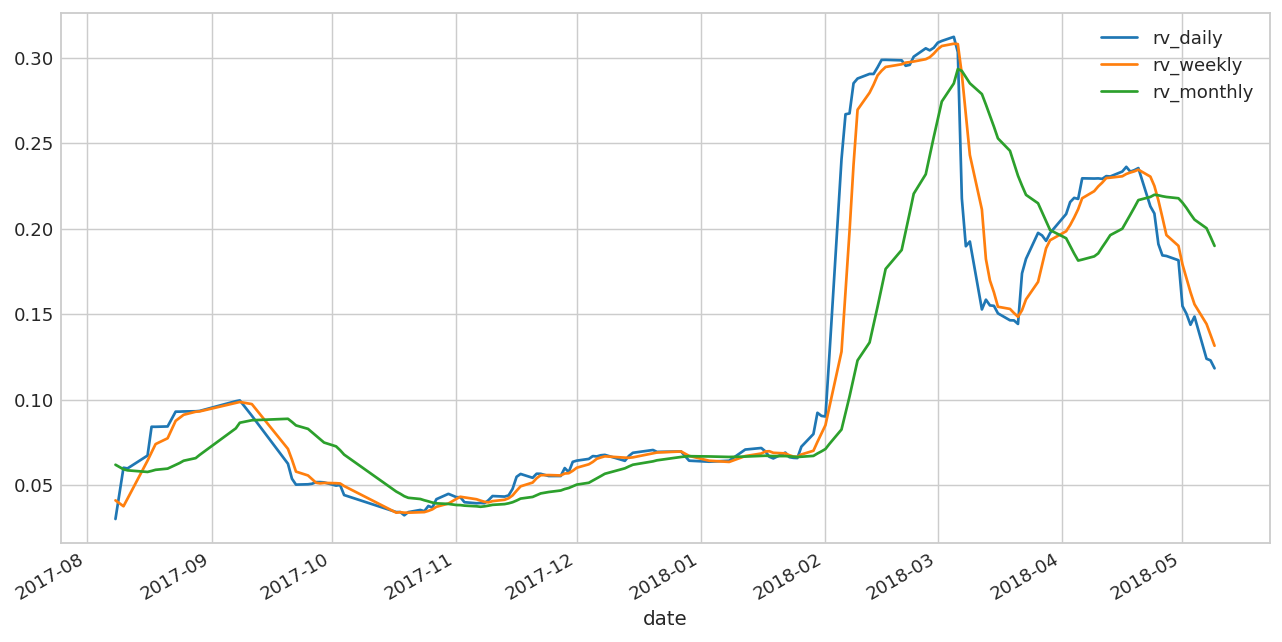

In [16]:
har_df[
    ['rv_daily', 'rv_weekly', 'rv_monthly']
].plot(figsize=(12,6))

har_df[
    ['rv_daily', 'rv_weekly', 'rv_monthly']
].corr()

In [17]:
import statsmodels.api as sm

X = har_df[
    [
        'rv_daily',
        'rv_weekly',
        'rv_monthly',
        'atm_iv',
        'convexity'
    ]
]

X = sm.add_constant(X)

y = har_df['rv_forward']

har_model = sm.OLS(y, X).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 21}
)

print(har_model.summary())

                            OLS Regression Results                            
Dep. Variable:             rv_forward   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     6.265
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.68e-05
Time:                        10:56:53   Log-Likelihood:                 182.72
No. Observations:                 153   AIC:                            -353.4
Df Residuals:                     147   BIC:                            -335.3
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0522      0.084      0.624      0.5

In [18]:
import statsmodels.api as sm

X = har_df[
    [
        'rv_past',
        'atm_iv',
        'convexity'
    ]
]

X = sm.add_constant(X)

y = har_df['rv_forward']

har_model = sm.OLS(y, X).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 21}
)

print(har_model.summary())

                            OLS Regression Results                            
Dep. Variable:             rv_forward   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     3.536
Date:                Sat, 30 May 2026   Prob (F-statistic):             0.0163
Time:                        10:56:53   Log-Likelihood:                 178.63
No. Observations:                 153   AIC:                            -349.3
Df Residuals:                     149   BIC:                            -337.1
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0463      0.074      0.628      0.5

DW low -> autocorrelation present

coeff better for analyse but p-values -> insignificant, just rv_past is a bit border

### 1.2 without overlap (rolling window)

In [19]:
for label, cols, names in [
    ("M1 : RV ~ ATM_IV",          ['atm_iv'],            ['Const', 'ATM_IV']),
    ("M2 : RV ~ PastRV",          ['rv_past'],            ['Const', 'PastRV']),
    ("M3 : RV ~ ATM_IV + PastRV", ['atm_iv', 'rv_past'], ['Const', 'ATM_IV', 'PastRV']),
]:
    data = reg_no[['rv_forward'] + cols].dropna()
    print(f"\n{'═'*62}\n{label}\n{'═'*62}")
    r = ols(data['rv_forward'], data[cols])
    reg_table(r, names)


══════════════════════════════════════════════════════════════
M1 : RV ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0217    0.0753    0.288    0.7796 
ATM_IV                    0.7185    0.5609    1.281    0.2322 
──────────────────────────────────────────────────────────────
R²                        0.1542
Adj. R²                   0.0602
N                             11
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001

══════════════════════════════════════════════════════════════
M2 : RV ~ PastRV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p

## 2 · Fixed Effects & Random Effects — IV Surface Panel

### 2.1 Motivation

A pooled OLS mixing all 22 expiries confounds two effects:
- The **causal** relationship: when IV rises, does future RV rise?
- The **term structure**: long-dated options have structurally higher IV

We verify this with an **F-test on entity fixed effects**:

$$F = \frac{(SSR_{\text{pooled}} - SSR_{\text{FE}})/(N-1)}{SSR_{\text{FE}}/(NT-N-K)} \sim F(N-1,\ NT-N-K)$$

### 2.2 Fixed Effects — within estimator

$$RV^{\text{fwd}}_t = \alpha_i + \beta_1 IV_{it} + \beta_2 \text{Conv}_{it} + \varepsilon_{it}$$

$\alpha_i$ absorbs the average IV level of each expiry. Identification from within-expiry deviations:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \qquad \tilde{x}_{it} = x_{it} - \bar{x}_i$$

### 2.3 Random Effects — GLS via quasi-demeaning

Assumes $\alpha_i \sim \mathcal{N}(0,\sigma^2_\alpha)$ uncorrelated with regressors.
Quasi-demeaning parameter:

$$\theta = 1 - \sqrt{\frac{\sigma^2_\varepsilon}{\sigma^2_\varepsilon + T\cdot\sigma^2_\alpha}}$$

### 2.4 Hausman test

$$H_0: \alpha_i \perp X_{it} \implies \text{RE consistent}$$

$$H = (\hat\beta_{FE}-\hat\beta_{RE})^\top[\text{Var}(\hat\beta_{FE})-\text{Var}(\hat\beta_{RE})]^{-1}(\hat\beta_{FE}-\hat\beta_{RE}) \sim \chi^2(K)$$

Reject $H_0$ → entity effects correlated with regressors → **FE is the consistent estimator**.

In [20]:
from linearmodels.panel import PanelOLS, RandomEffects

# ── Panel construction ─────────────────────────────────────────────────────────
panel_surf = build_surface_panel(df, reg_overlap,
                                 wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                 wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

# ── Ajout du VIX_ATM_Spread (varie par date, broadcast sur toutes les expiries) ─
vix_norm = reg['vix'] / 100
panel_surf['vix_norm'] = panel_surf['date'].map(vix_norm)
panel_surf['vix_atm_spread'] = panel_surf['vix_norm'] - panel_surf['atm_iv']
panel_surf = panel_surf.dropna(subset=['vix_atm_spread'])

x_cols = ['atm_iv', 'vix_atm_spread']

print(f"Panel: {len(panel_surf)} obs  |  {panel_surf['expiry'].nunique()} expiries  |  {panel_surf['date'].nunique()} dates")

# ── F-test: are entity fixed effects significant? ──────────────────────────────
r_pooled = ols(panel_surf['rv_forward'].values, panel_surf[x_cols].values)
fe_surf  = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')
N, NT, K = panel_surf['expiry'].nunique(), len(panel_surf), len(x_cols)
F_stat   = ((np.sum(r_pooled['resid']**2) - np.sum(fe_surf.resid**2)) / (N-1)) / \
            (np.sum(fe_surf.resid**2) / (NT - N - K))
F_p      = 1 - stats.f.cdf(F_stat, N-1, NT-N-K)
print(f"\nF-test entity effects : F = {F_stat:.3f},  p = {F_p:.4f}  → {'Significant ✓' if F_p < 0.05 else 'Not significant'}")

# ── Fixed Effects & Random Effects (linearmodels) ──────────────────────────────
panel_idx = panel_surf.set_index(['expiry', 'date'])
y_pan = panel_idx['rv_forward']
X_pan = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
re_lm = RandomEffects(y_pan, X_pan).fit()

print('\n' + '═'*62)
print('FIXED EFFECTS'); print(fe_lm.summary.tables[1])
print('\n' + '═'*62)
print('RANDOM EFFECTS'); print(re_lm.summary.tables[1])

Panel: 2240 obs  |  21 expiries  |  211 dates

F-test entity effects : F = 17.040,  p = 0.0000  → Significant ✓

══════════════════════════════════════════════════════════════
FIXED EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
atm_iv             0.0026     0.0867     0.0295     0.9765     -0.1674      0.1726
vix_atm_spread     0.6518     0.0517     12.600     0.0000      0.5504      0.7533

══════════════════════════════════════════════════════════════
RANDOM EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0965     0.0124     7.7706     0.0000      0.0

### 2.4 Hausman test — choosing between FE and RE

$$H_0: \alpha_i \perp X_{it} \quad \Rightarrow \text{RE consistent and efficient}$$

$$H = (\hat\beta_{FE} - \hat\beta_{RE})^\top\,[\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE} - \hat\beta_{RE}) \sim \chi^2(K)$$

- **Reject** $H_0$: expiry effects correlated with regressors → only **FE** is consistent
- **Cannot reject**: RE is consistent and more efficient → **prefer RE**

In [21]:
b_fe  = fe_lm.params.values
b_re  = re_lm.params[x_cols].values
V_fe  = fe_lm.cov.values
V_re  = re_lm.cov.loc[x_cols, x_cols].values
diff  = b_fe - b_re
H     = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p     = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f"Hausman : stat={H:.4f}  p={p:.4f}")

Hausman : stat=12.9536  p=0.0015


### Conclusion : 
fixed effect within expiries

# 3.1 ARMA new

In [22]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

# Use overlapping series for enough observations
# exog = the X variables entering contemporaneously
exog = reg_overlap[['atm_iv', 'convexity']].dropna()
endog = reg_overlap['rv_forward'].dropna()

# Align indices
common_idx = exog.index.intersection(endog.index)
exog = exog.loc[common_idx]
endog = endog.loc[common_idx]

In [23]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg_overlap['rv_forward'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

rv_diff = reg_overlap['rv_forward'].dropna().diff().dropna()
result_diff = adfuller(rv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

ADF Statistic: -1.9368
p-value: 0.3150
ADF on first difference: stat=-5.9908, p=0.0000


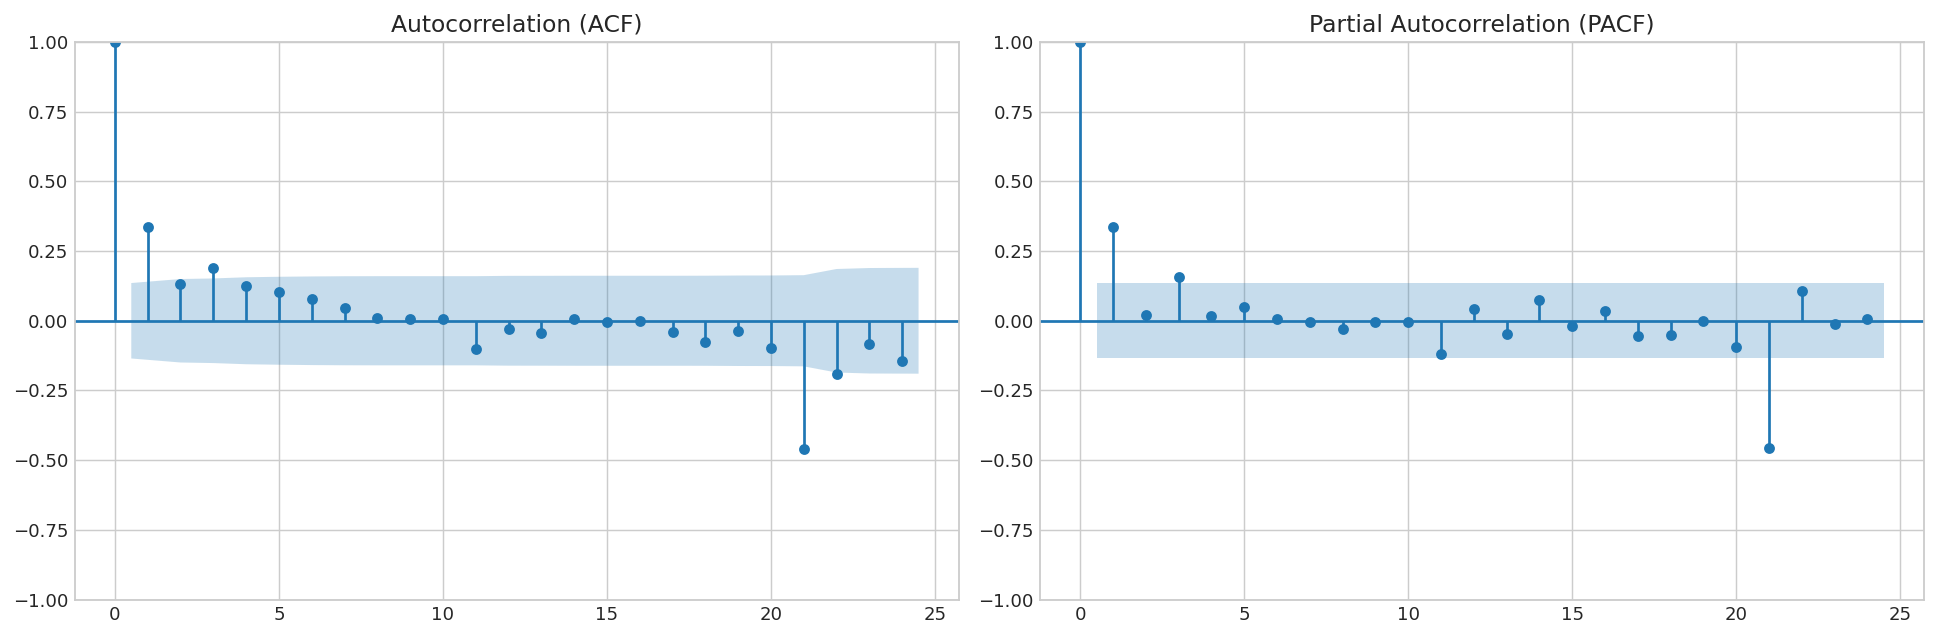

In [24]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(rv_diff, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF)")

plot_pacf(rv_diff, ax=axes[1])
axes[1].set_title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()

In [25]:
# identfy p and q

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model_armax = ARIMA(endog, exog=exog, order=(p, 1, q)).fit()
        if model_armax.aic < best_aic:
            best_aic = model_armax.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=1, q={best_q}) with AIC={best_aic:.2f}")

model_armax = ARIMA(endog, exog=exog, order=(best_p, 1, best_q)).fit()
print(model_armax.summary())

Best ARIMA order: (p=1, d=1, q=0) with AIC=-926.05
                               SARIMAX Results                                
Dep. Variable:             rv_forward   No. Observations:                  163
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 467.027
Date:                Sat, 30 May 2026   AIC                           -926.054
Time:                        10:57:08   BIC                           -913.704
Sample:                             0   HQIC                          -921.040
                                - 163                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
atm_iv        -0.1842      0.046     -4.004      0.000      -0.274      -0.094
convexity     -0.1683      0.085     -1.978      0.048      -0.335      -0.002
a

Higher ATM implied volatility today predicts lower changes in future realized volatility.

more convex smiles predict lower future increases in realized vol.

kurtosis high

JB huge -> residuals non gaussian

heteroskedasticty : variance not constant

In [26]:
# ljung-box test : check that autocorr is low
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model_armax.resid, lags=10)

,lb_stat,lb_pvalue
1,0.057295,0.810823
2,0.279033,0.869778
3,1.252536,0.740434
4,1.316176,0.858625
5,1.350043,0.929699
6,1.406631,0.965454
7,1.420126,0.984947
8,1.485826,0.992941
9,1.610234,0.996243
10,1.664032,0.998327


We fail to reject the null hypothesis of no autocorrelation in residuals.

In [27]:
# same with skew

from statsmodels.tsa.arima.model import ARIMA
import itertools

# Use overlapping series for enough observations
# exog = the X variables entering contemporaneously
exog = reg_overlap[['atm_iv', 'convexity', 'skew']].dropna()
endog = reg_overlap['rv_forward'].dropna()

# Align indices
common_idx = exog.index.intersection(endog.index)
exog = exog.loc[common_idx]
endog = endog.loc[common_idx]

# identfy p and q

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model_armax = ARIMA(endog, exog=exog, order=(p, 1, q)).fit()
        if model_armax.aic < best_aic:
            best_aic = model_armax.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=1, q={best_q}) with AIC={best_aic:.2f}")

model_armax = ARIMA(endog, exog=exog, order=(best_p, 1, best_q)).fit()
print(model_armax.summary())

# ljung-box test : check that autocorr is low
acorr_ljungbox(model_armax.resid, lags=10)

Best ARIMA order: (p=1, d=1, q=0) with AIC=-924.06
                               SARIMAX Results                                
Dep. Variable:             rv_forward   No. Observations:                  163
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 467.028
Date:                Sat, 30 May 2026   AIC                           -924.055
Time:                        10:57:14   BIC                           -908.617
Sample:                             0   HQIC                          -917.787
                                - 163                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
atm_iv        -0.1830      0.047     -3.898      0.000      -0.275      -0.091
convexity     -0.1682      0.106     -1.586      0.113      -0.376       0.040
s

,lb_stat,lb_pvalue
1,0.056090,0.812786
2,0.282051,0.868467
3,1.263941,0.737713
4,1.325988,0.856951
5,1.357361,0.928920
6,1.411095,0.965180
7,1.423517,0.984840
8,1.488567,0.992896
9,1.611462,0.996232
10,1.667346,0.998313


skew non significant 

ARMA non overlap with rolling window

In [28]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg_nonoverlap['rv_forward'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

rv_diff = reg_nonoverlap['rv_forward'].dropna().diff().dropna()
result_diff = adfuller(rv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

ADF Statistic: -1.9553
p-value: 0.3065
ADF on first difference: stat=-5.0083, p=0.0000


In [29]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

# exog = the X variables entering contemporaneously
exog = reg_nonoverlap[['atm_iv', 'convexity', 'skew']].dropna()
endog = reg_nonoverlap['rv_forward'].dropna()

# Align indices
common_idx = exog.index.intersection(endog.index)
exog = exog.loc[common_idx]
endog = endog.loc[common_idx]

# identfy p and q

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model_armax = ARIMA(endog, exog=exog, order=(p, 1, q)).fit()
        if model_armax.aic < best_aic:
            best_aic = model_armax.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=1, q={best_q}) with AIC={best_aic:.2f}")

model_armax = ARIMA(endog, exog=exog, order=(best_p, 1, best_q)).fit()
print(model_armax.summary())

# ljung-box test : check that autocorr is low
acorr_ljungbox(model_armax.resid, lags=8)

Best ARIMA order: (p=3, d=1, q=0) with AIC=-31.57
                               SARIMAX Results                                
Dep. Variable:             rv_forward   No. Observations:                    9
Model:                 ARIMA(3, 1, 0)   Log Likelihood                  22.785
Date:                Sat, 30 May 2026   AIC                            -31.570
Time:                        10:57:18   BIC                            -31.014
Sample:                             0   HQIC                           -35.321
                                  - 9                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
atm_iv        -2.6303      1.357     -1.939      0.053      -5.289       0.029
convexity     -5.7044      2.910     -1.960      0.050     -11.408      -0.001
sk

,lb_stat,lb_pvalue
1,0.011503,0.914588
2,0.942365,0.624264
3,1.021968,0.795937
4,1.037622,0.904039
5,1.085327,0.955394
6,1.164168,0.978618
7,1.457805,0.983735
8,2.164673,0.975543


problems : we have 3 AR coefficients, 3 exogenous coefficients, variance parameter,
differencing structure. That is huge relative to sample size.

coeff are huge 

We fail to reject the null hypothesis of no autocorrelation in residuals.

# 3.2 ARMA old
(for a single TS -> atm_iv)

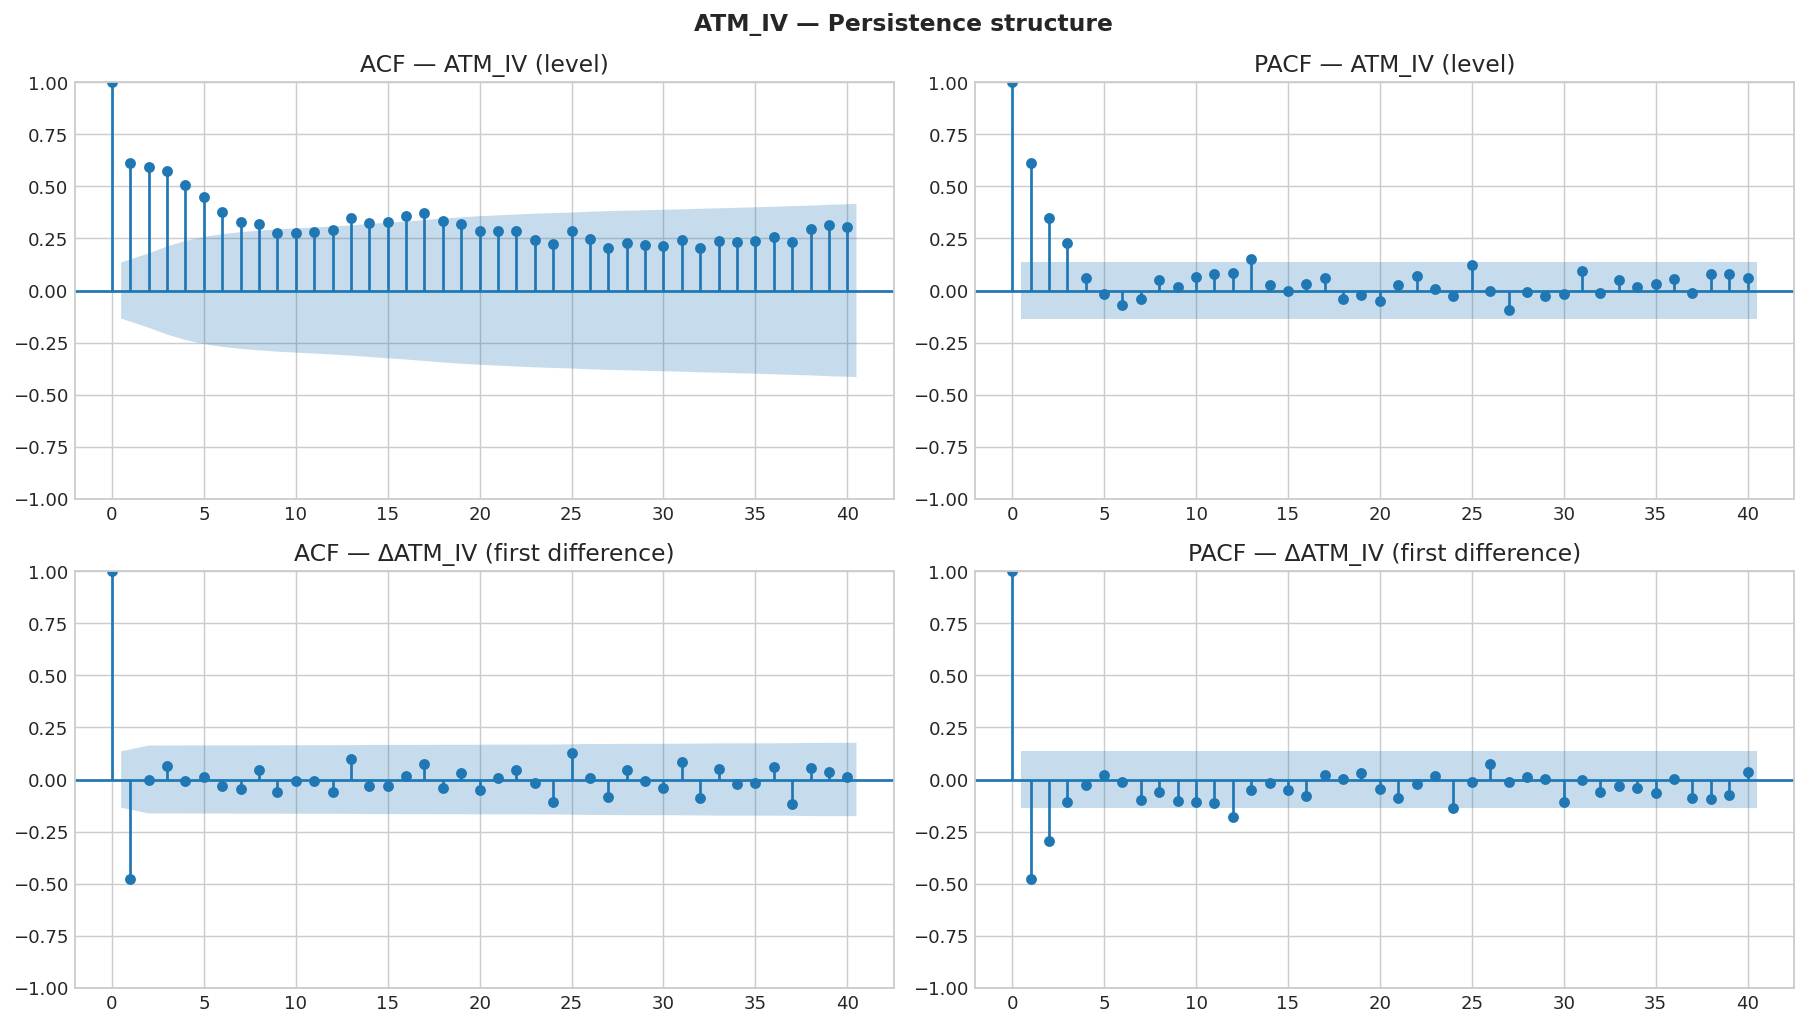

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF et PACF en niveau
plot_acf(reg['atm_iv'].dropna(), lags=40, ax=axes[0,0], 
         title='ACF — ATM_IV (level)')
plot_pacf(reg['atm_iv'].dropna(), lags=40, ax=axes[0,1], 
          title='PACF — ATM_IV (level)')

# ACF et PACF en différence première
atm_iv_diff = reg['atm_iv'].dropna().diff().dropna()
plot_acf(atm_iv_diff, lags=40, ax=axes[1,0], 
         title='ACF — ΔATM_IV (first difference)')
plot_pacf(atm_iv_diff, lags=40, ax=axes[1,1], 
          title='PACF — ΔATM_IV (first difference)')

plt.suptitle('ATM_IV — Persistence structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.3225
p-value: 0.0139


p<0.05 now -> it is stationnary

Best ARIMA order: (p=3, d=0, q=0) with AIC=-886.45


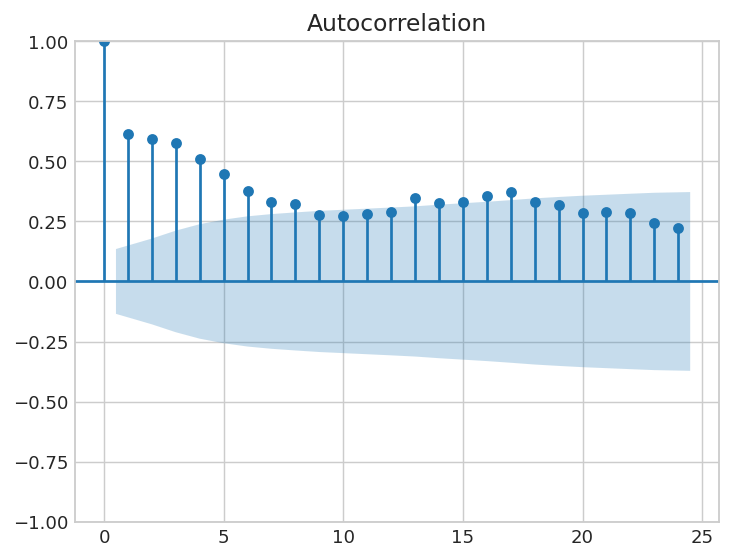

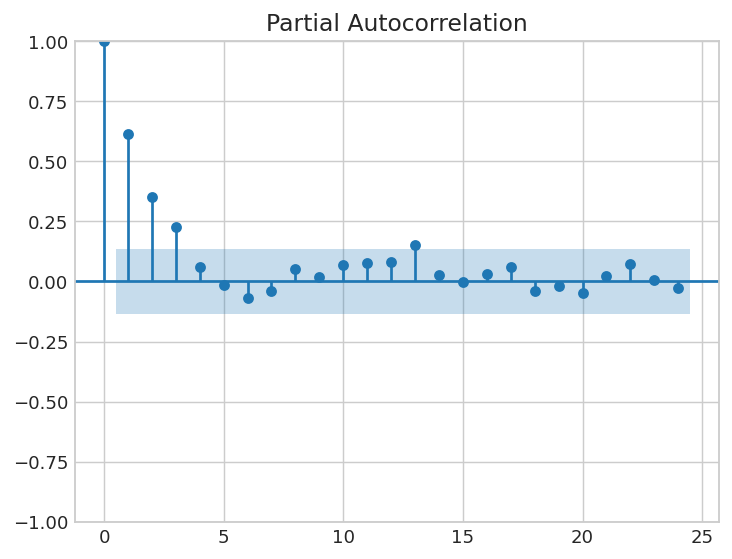

In [32]:
# identfy p and q

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(reg['atm_iv'].dropna())  # gives p
plot_pacf(reg['atm_iv'].dropna())   # gives q

from statsmodels.tsa.arima.model import ARIMA
import itertools

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model = ARIMA(reg['atm_iv'].dropna(), order=(p,0,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=0, q={best_q}) with AIC={best_aic:.2f}")

In [33]:
model = ARIMA(reg['atm_iv'].dropna(), order=(best_p,0,best_q)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                 atm_iv   No. Observations:                  211
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 448.226
Date:                Sat, 30 May 2026   AIC                           -886.451
Time:                        10:57:25   BIC                           -869.692
Sample:                             0   HQIC                          -879.677
                                - 211                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1282      0.020      6.425      0.000       0.089       0.167
ar.L1          0.3151      0.041      7.624      0.000       0.234       0.396
ar.L2          0.2600      0.081      3.225      0.0

Kurtosis = 88.21 → extreme fat tails (normal distribution has kurtosis = 3)

JB huge -> residuals non gaussian

heteroskedasticity : we reject it, the variance is not constant

In [34]:
# ljung-box test : check that autocorr is low
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model.resid, lags=10)

,lb_stat,lb_pvalue
1,0.034929,0.851744
2,0.094999,0.953611
3,0.115030,0.989975
4,1.523140,0.822535
5,1.640103,0.896358
6,2.156801,0.904727
7,3.115010,0.874163
8,3.121464,0.926505
9,4.154511,0.900952
10,4.915395,0.896758


p-value > 0.05, residuals are WN

Recap ARMA : for now just did with atm_iv, test with vix or skew or convexity ?

## 4. Cointegration

In [35]:
from statsmodels.tsa.stattools import coint, adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# ── 1. Préparer les données ────────────────────────────────────────────────────
data_coint = reg[['atm_iv', 'rv_past']].dropna().copy()
data_coint['vix_norm'] = reg['vix'] / 100
data_coint = data_coint.dropna()

# ── 2. Vérifier I(1) : ADF  ───────────────────────────
def integration_order(series, name):
    # ADF : H0 = unit root
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC')
    
    adf_reject = adf_p < 0.05  # reject H0 → stationary
    
    if adf_reject:
        conclusion = "I(0) — stationary"
    else:
        conclusion = "I(1) — cannot reject unit root"
    
    print(f"{name:<12} ADF stat={adf_stat:.4f}  p={adf_p:.4f} "
          f"{'[reject H0]' if adf_reject else '[fail to reject]'}  → {conclusion}")

print("═"*72)
print("INTEGRATION order")
print("═"*72)
for col, name in [('atm_iv','ATM_IV'), ('rv_past','RV_past'), ('vix_norm','VIX_norm')]:
    integration_order(data_coint[col], name)

# ── 3. Engle-Granger dans les deux sens ───────────────────────────────────────
print("\n" + "═"*72)
print("ENGLE-GRANGER (two directions)")
print("═"*72)
pairs = [
    ('vix_norm', 'atm_iv',  'VIX → ATM_IV'),
    ('atm_iv',   'vix_norm','ATM_IV → VIX'),
    ('vix_norm', 'rv_past', 'VIX → RV_past'),
    ('rv_past',  'vix_norm','RV_past → VIX'),
    ('atm_iv',   'rv_past', 'ATM_IV → RV_past'),
    ('rv_past',  'atm_iv',  'RV_past → ATM_IV'),
]
for x, y, label in pairs:
    _, p, _ = coint(data_coint[x], data_coint[y])
    print(f"  {label:<22} p = {p:.4f}  {'COINTEGRATED ✓' if p < 0.05 else 'not cointegrated'}")

# ── 4. Johansen (symétrique, rang de cointégration) ───────────────────────────
print("\n" + "═"*72)
print("JOHANSEN — cointegration rank  (det_order=0, k_ar_diff=1)")
print("═"*72)
res_joh = coint_johansen(data_coint[['vix_norm', 'atm_iv', 'rv_past']],
                         det_order=0, k_ar_diff=1)

print("\nTrace statistic vs critical values (90% / 95% / 99%)")
print(f"{'H0: rang ≤':<12} {'Trace stat':>12} {'CV 90%':>10} {'CV 95%':>10} {'CV 99%':>10}")
print("-"*56)
for i in range(len(res_joh.lr1)):
    ts  = res_joh.lr1[i]
    cvs = res_joh.cvt[i]   # [90%, 95%, 99%]
    reject = "← reject" if ts > cvs[1] else ""
    print(f"  r ≤ {i:<8} {ts:>12.3f} {cvs[0]:>10.3f} {cvs[1]:>10.3f} {cvs[2]:>10.3f}  {reject}")

════════════════════════════════════════════════════════════════════════
INTEGRATION order
════════════════════════════════════════════════════════════════════════
ATM_IV       ADF stat=-3.3225  p=0.0139 [reject H0]  → I(0) — stationary
RV_past      ADF stat=-1.9094  p=0.3277 [fail to reject]  → I(1) — cannot reject unit root
VIX_norm     ADF stat=-2.5859  p=0.0959 [fail to reject]  → I(1) — cannot reject unit root

════════════════════════════════════════════════════════════════════════
ENGLE-GRANGER (two directions)
════════════════════════════════════════════════════════════════════════
  VIX → ATM_IV           p = 0.1168  not cointegrated
  ATM_IV → VIX           p = 0.0025  COINTEGRATED ✓
  VIX → RV_past          p = 0.0015  COINTEGRATED ✓
  RV_past → VIX          p = 0.0027  COINTEGRATED ✓
  ATM_IV → RV_past       p = 0.0025  COINTEGRATED ✓
  RV_past → ATM_IV       p = 0.1364  not cointegrated

════════════════════════════════════════════════════════════════════════
JOHANSEN — co

## 5.VAR - new

with rv_past, atm_iv and convexity

In [48]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg_overlap['rv_past'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

rv_diff = reg_overlap['rv_past'].dropna().diff().dropna()
result_diff = adfuller(rv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

result = adfuller(reg_overlap['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

result = adfuller(reg_overlap['convexity'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -1.9094
p-value: 0.3277
ADF on first difference: stat=-5.9468, p=0.0000
ADF Statistic: -3.3225
p-value: 0.0139
ADF Statistic: -4.5923
p-value: 0.0001


In [59]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'rv_past_diff' : reg_overlap['rv_past'].diff(),  # diff to ensure stationarity
    'atm_iv'   : reg_overlap['atm_iv'],   # ok stat
    'convexity' : reg_overlap['convexity']         # ok stat
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)

lag_order_results = model_var.select_order(maxlags=10)
print("Lag order selection:")
print(lag_order_results.summary())

              rv_past_diff    atm_iv  convexity
rv_past_diff      1.000000  0.491128  -0.285269
atm_iv            0.491128  1.000000  -0.586474
convexity        -0.285269 -0.586474   1.000000

Lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -23.14      -23.08   8.896e-11      -23.12
1       -24.57     -24.34*   2.126e-11      -24.48
2       -24.73      -24.31   1.822e-11     -24.56*
3      -24.74*      -24.15  1.795e-11*      -24.50
4       -24.66      -23.88   1.961e-11      -24.34
5       -24.65      -23.70   1.975e-11      -24.26
6       -24.62      -23.49   2.041e-11      -24.16
7       -24.59      -23.28   2.110e-11      -24.06
8       -24.53      -23.05   2.239e-11      -23.93
9       -24.47      -22.81   2.391e-11      -23.79
10      -24.40      -22.56   2.567e-11      -23.65
--------------------------------------------------


In [60]:
results = model_var.fit(1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 30, May, 2026
Time:                     11:58:52
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.4687
Nobs:                     162.000    HQIC:                  -24.6045
Log likelihood:           1322.89    FPE:                1.87960e-11
AIC:                     -24.6974    Det(Omega_mle):     1.74697e-11
--------------------------------------------------------------------
Results for equation rv_past_diff
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.001328         0.005543           -0.240           0.811
L1.rv_past_diff         0.377978         0.085135            4.440           0.000
L1.atm_iv               0.000396         0.03

multi coll : ok accroding to the corr matrix

for rv_past_diff equation : rv_past diff is signif, atm_iv and convexity NO !

for atm_iv equation : atm_iv related to past atm_iv + past convexity

convexity -> only convexity

In [61]:
# Fit with BIC-selected lag
results_bic = model_var.fit(1)   # BIC selection
results_aic = model_var.fit(3)   # AIC selection

# Compare Granger results under both
print("=== VAR(1) - BIC ===")
print(results_bic.test_causality('rv_past_diff', ['atm_iv', 'convexity'], kind='f'))

print("=== VAR(3) - AIC ===")
print(results_aic.test_causality('rv_past_diff', ['atm_iv', 'convexity'], kind='f'))

=== VAR(1) - BIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['atm_iv', 'convexity'] do not Granger-cause rv_past_diff: fail to reject at 5% significance level. Test statistic: 0.789, critical value: 3.015>, p-value: 0.455>
=== VAR(3) - AIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['atm_iv', 'convexity'] do not Granger-cause rv_past_diff: fail to reject at 5% significance level. Test statistic: 1.486, critical value: 2.119>, p-value: 0.181>


H0​: ATM IV and Convexity do not Granger-cause ΔRV (rv_past), not future

we fail to reject in both choices of IC

In [62]:
# Fit with BIC-selected lag
results_bic = model_var.fit(1)   # BIC selection
results_aic = model_var.fit(3)   # AIC selection

# Compare Granger results under both
print("=== VAR(1) - BIC ===")
print(results_bic.test_causality('atm_iv', ['rv_past_diff'], kind='f'))

print("=== VAR(3) - AIC ===")
print(results_aic.test_causality('atm_iv', ['rv_past_diff'], kind='f'))

=== VAR(1) - BIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: rv_past_diff does not Granger-cause atm_iv: fail to reject at 5% significance level. Test statistic: 0.390, critical value: 3.861>, p-value: 0.533>
=== VAR(3) - AIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: rv_past_diff does not Granger-cause atm_iv: fail to reject at 5% significance level. Test statistic: 0.640, critical value: 2.625>, p-value: 0.589>


same conclusion

In [63]:
# Fit with BIC-selected lag
results_bic = model_var.fit(1)   # BIC selection
results_aic = model_var.fit(3)   # AIC selection

# Compare Granger results under both
print("=== VAR(1) - BIC ===")
print(results_bic.test_causality('convexity', ['rv_past_diff'], kind='f'))

print("=== VAR(3) - AIC ===")
print(results_aic.test_causality('convexity', ['rv_past_diff'], kind='f'))

=== VAR(1) - BIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: rv_past_diff does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 1.491, critical value: 3.861>, p-value: 0.223>
=== VAR(3) - AIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: rv_past_diff does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 0.379, critical value: 2.625>, p-value: 0.768>


same conclusion

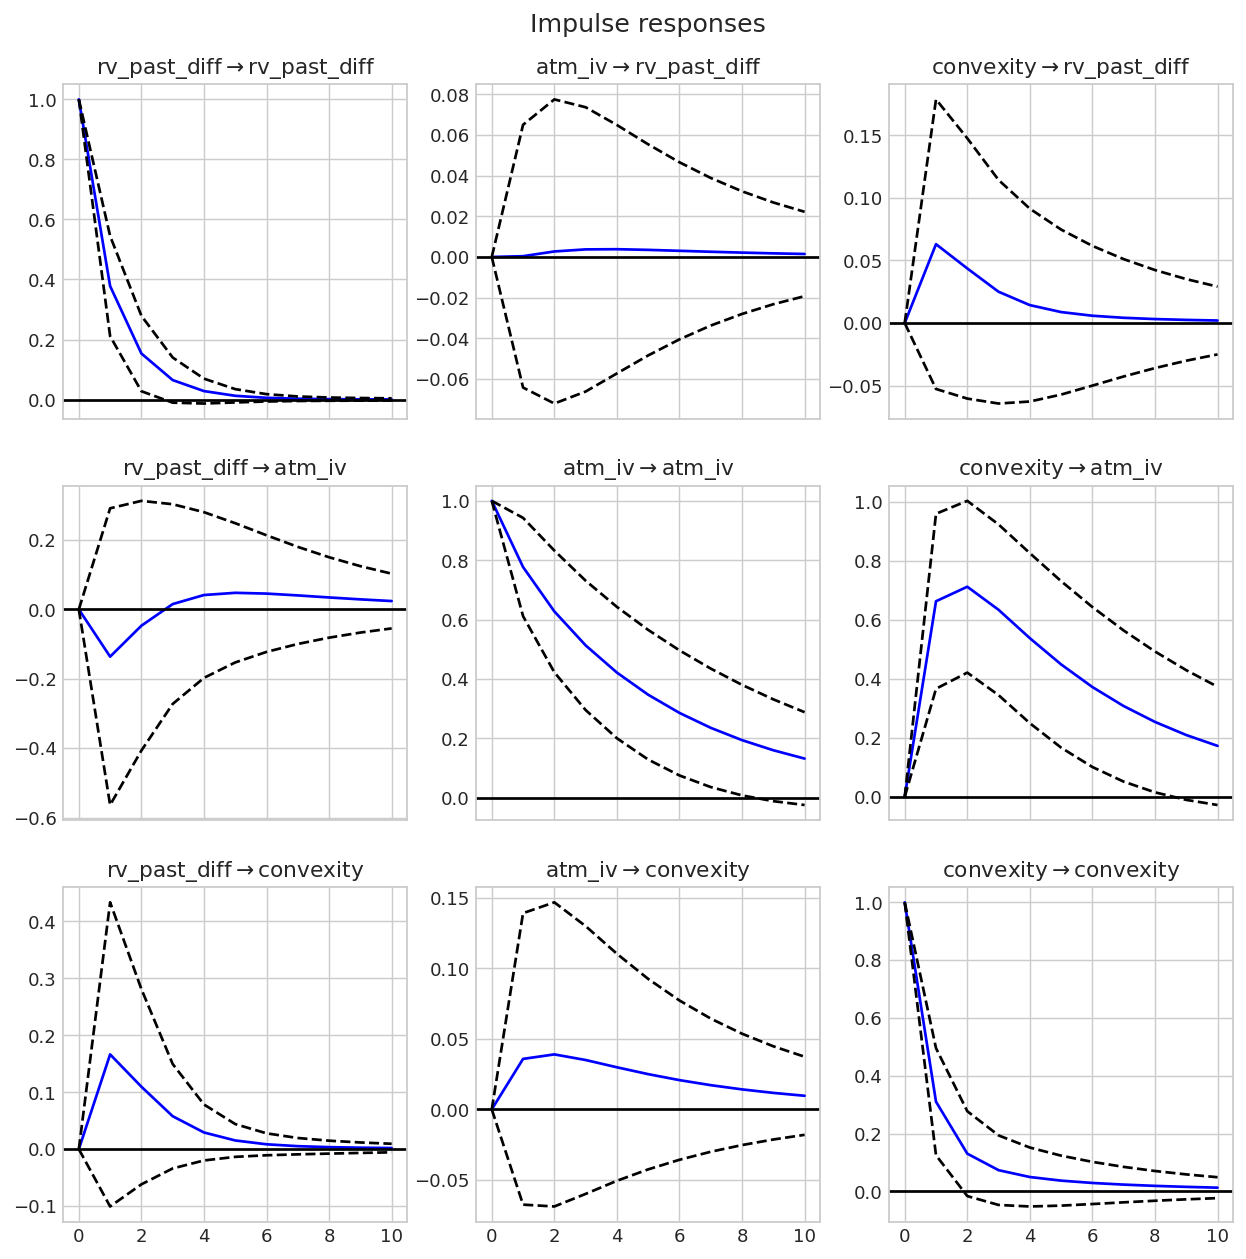

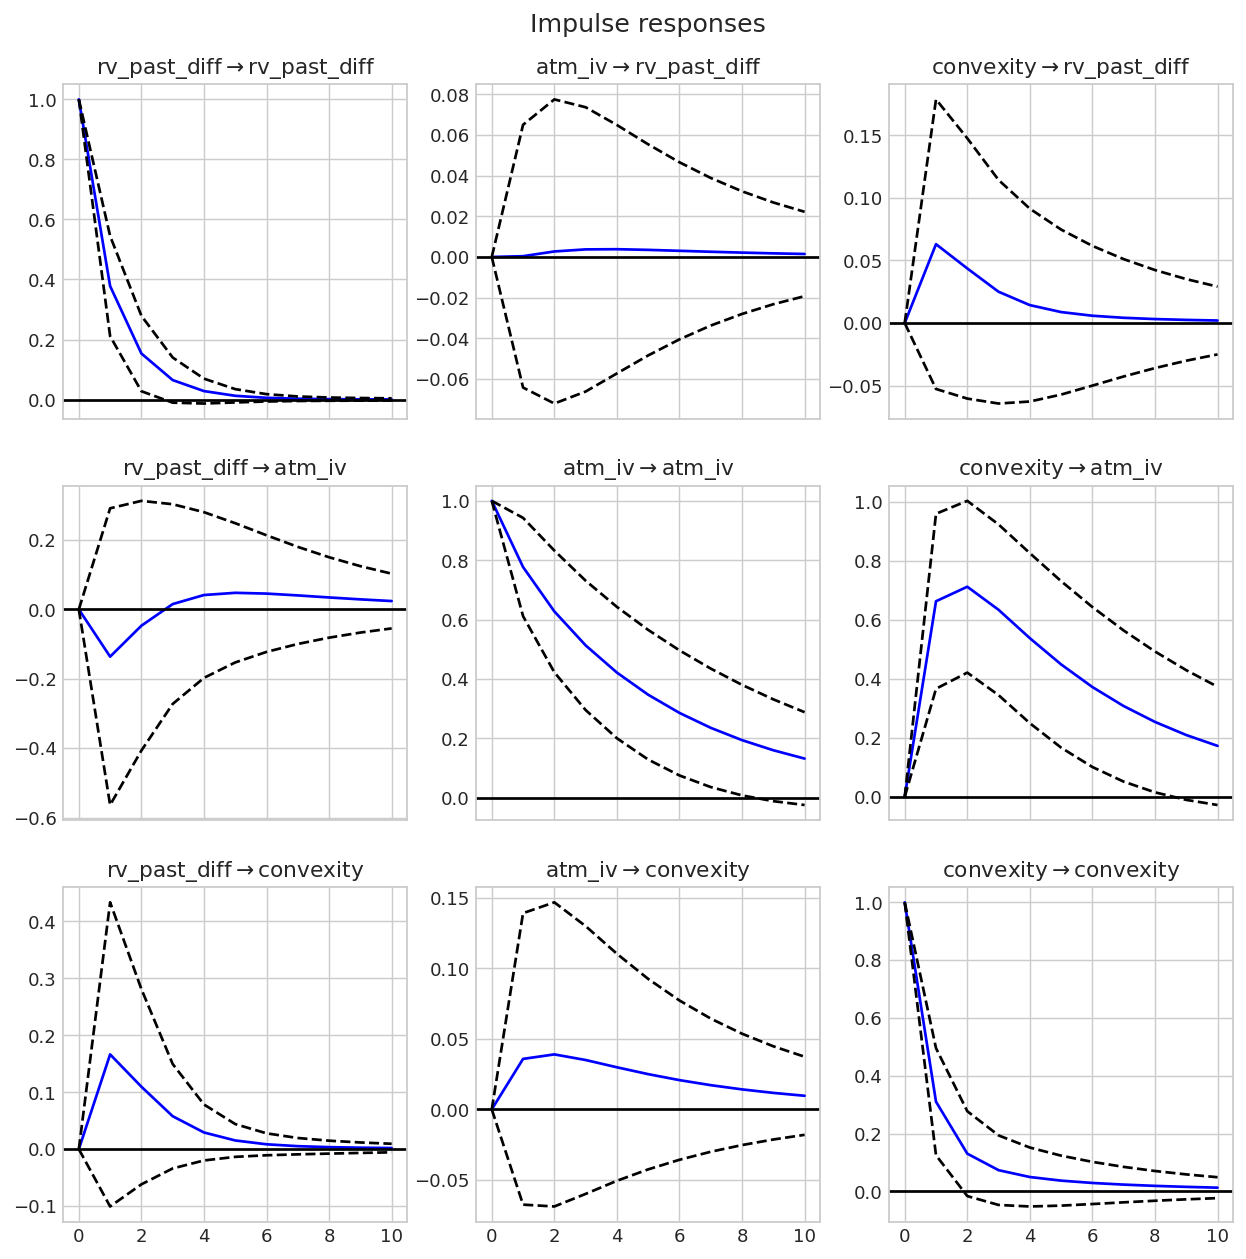

In [64]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

read the IR : \
on the rows : variable that receive the shock \
on the columns : varaibel that responds \
example on the bottom left : how atm_iv responds to conv shock \
black lines : confidence interval

SKEW en plus dans la VAR

In [65]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'rv_past_diff' : reg_overlap['rv_past'].diff(),  # diff to ensure stationarity
    'atm_iv'   : reg_overlap['atm_iv'],
    'skew'     : reg_overlap['skew'],      # ok stat
    'convexity' : reg_overlap['convexity']         # ok stat
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)

lag_order_results = model_var.select_order(maxlags=10)
print("Lag order selection:")
print(lag_order_results.summary())

              rv_past_diff    atm_iv      skew  convexity
rv_past_diff      1.000000  0.491128  0.539497  -0.285269
atm_iv            0.491128  1.000000  0.467811  -0.586474
skew              0.539497  0.467811  1.000000  -0.226771
convexity        -0.285269 -0.586474 -0.226771   1.000000

Lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -30.62      -30.54   5.019e-14      -30.59
1       -32.74     -32.35*   6.029e-15      -32.58
2      -32.94*      -32.23  4.940e-15*     -32.65*
3       -32.86      -31.83   5.350e-15      -32.44
4       -32.71      -31.37   6.220e-15      -32.17
5       -32.65      -30.99   6.663e-15      -31.97
6       -32.58      -30.59   7.210e-15      -31.77
7       -32.50      -30.20   7.858e-15      -31.56
8       -32.38      -29.76   8.934e-15      -31.31
9       -32.24      -29.30   1.040e-14      -31.05
10      -32.12      -28.8

In [66]:
results = model_var.fit(1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 30, May, 2026
Time:                     12:15:45
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -32.5263
Nobs:                     162.000    HQIC:                  -32.7527
Log likelihood:           1766.03    FPE:                5.11085e-15
AIC:                     -32.9075    Det(Omega_mle):     4.52572e-15
--------------------------------------------------------------------
Results for equation rv_past_diff
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.001544         0.005980           -0.258           0.796
L1.rv_past_diff         0.374293         0.093281            4.013           0.000
L1.atm_iv              -0.000524         0.03

without skew, with sp500 daily returns 

In [67]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(np.log(spot_ts / spot_ts.shift(1)).dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -6.4767
p-value: 0.0000


In [68]:
from statsmodels.tsa.vector_ar.var_model import VAR

ret = np.log(spot_ts / spot_ts.shift(1))

delta_var = pd.DataFrame({
    'rv_past_diff': reg_overlap['rv_past'].diff(),
    'atm_iv': reg_overlap['atm_iv'],
    'convexity': reg_overlap['convexity'],
    'ret': ret.reindex(reg_overlap.index)
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)

lag_order_results = model_var.select_order(maxlags=10)
print("Lag order selection:")
print(lag_order_results.summary())

              rv_past_diff    atm_iv  convexity       ret
rv_past_diff      1.000000  0.491128  -0.285269 -0.408845
atm_iv            0.491128  1.000000  -0.586474 -0.380470
convexity        -0.285269 -0.586474   1.000000  0.202838
ret              -0.408845 -0.380470   0.202838  1.000000

Lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -32.57      -32.50   7.130e-15      -32.54
1       -34.49     -34.09*   1.053e-15      -34.33
2       -34.72      -34.01   8.341e-16     -34.43*
3      -34.77*      -33.74  7.914e-16*      -34.36
4       -34.61      -33.26   9.384e-16      -34.06
5       -34.62      -32.95   9.304e-16      -33.94
6       -34.57      -32.59   9.829e-16      -33.76
7       -34.56      -32.27   9.928e-16      -33.63
8       -34.48      -31.87   1.086e-15      -33.42
9       -34.45      -31.51   1.142e-15      -33.25
10      -34.51      -31.2

In [69]:
results = model_var.fit(1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 30, May, 2026
Time:                     12:26:07
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -34.2857
Nobs:                     162.000    HQIC:                  -34.5121
Log likelihood:           1908.55    FPE:                8.79808e-16
AIC:                     -34.6669    Det(Omega_mle):     7.79080e-16
--------------------------------------------------------------------
Results for equation rv_past_diff
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.000601         0.005591            0.108           0.914
L1.rv_past_diff         0.332246         0.087808            3.784           0.000
L1.atm_iv              -0.012885         0.03

In [70]:
# Fit with BIC-selected lag
results_bic = model_var.fit(1)   # BIC selection
results_aic = model_var.fit(3)   # AIC selection

# Compare Granger results under both
print("=== VAR(1) - BIC ===")
print(results_bic.test_causality('rv_past_diff', ['ret'], kind='f'))

print("=== VAR(3) - AIC ===")
print(results_aic.test_causality('rv_past_diff', ['ret'], kind='f'))

=== VAR(1) - BIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause rv_past_diff: fail to reject at 5% significance level. Test statistic: 3.607, critical value: 3.856>, p-value: 0.058>
=== VAR(3) - AIC ===
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause rv_past_diff: fail to reject at 5% significance level. Test statistic: 0.702, critical value: 2.620>, p-value: 0.551>


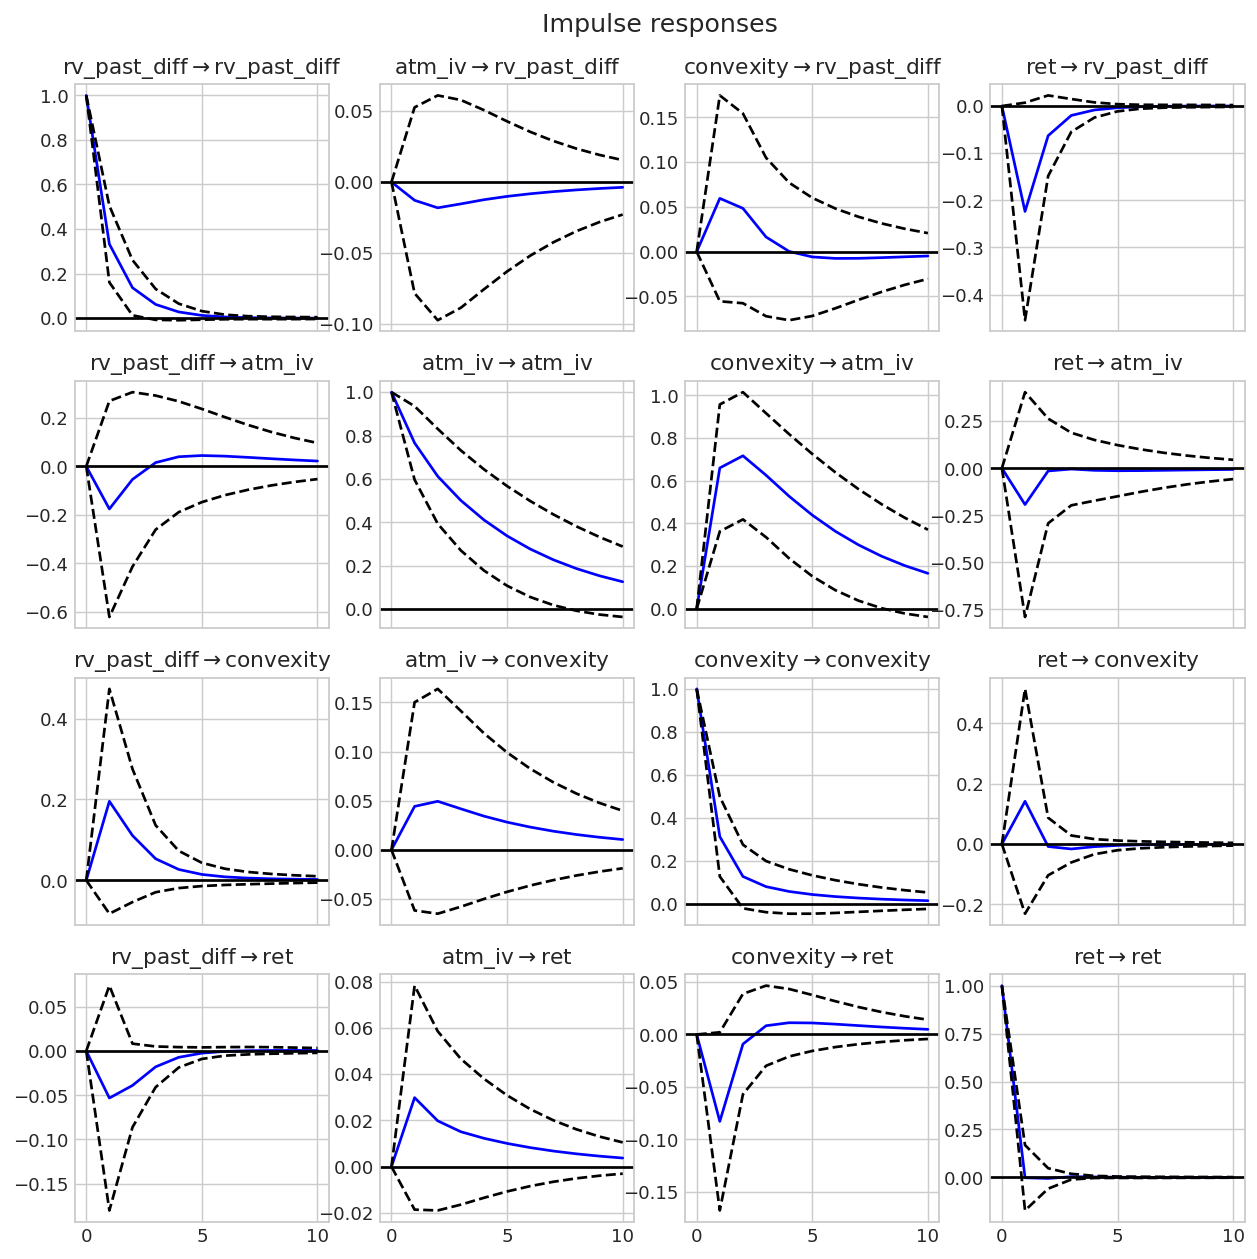

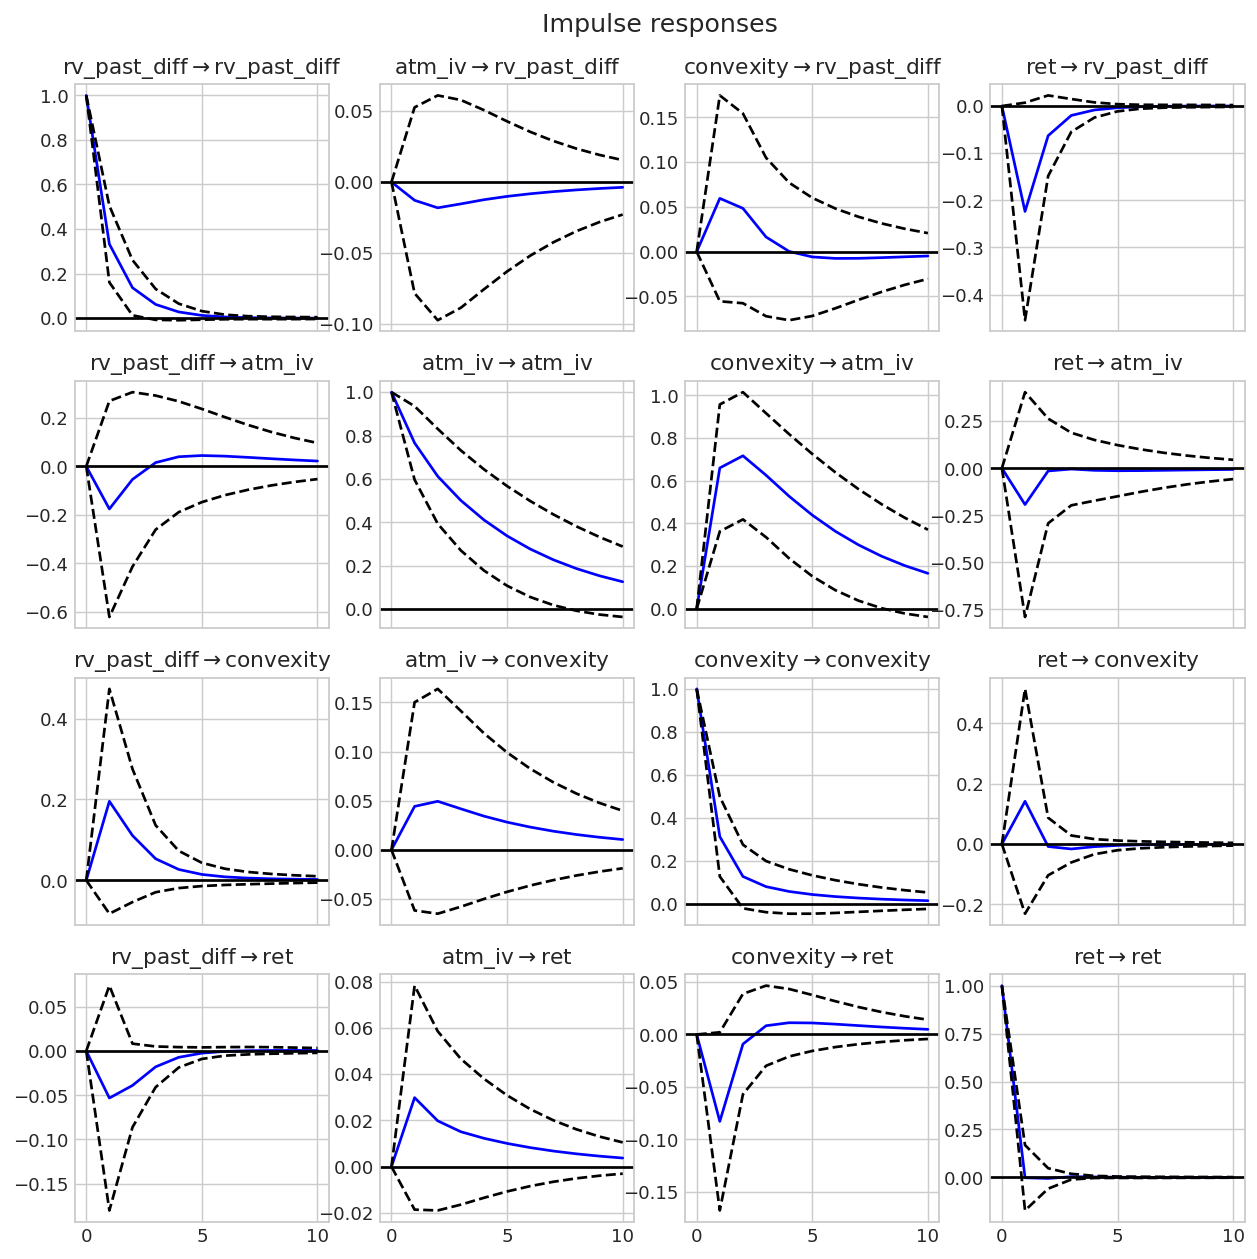

In [71]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

### VECM

In [46]:
from statsmodels.tsa.vector_ar.vecm import VECM

vecm = VECM(data_coint[['vix_norm', 'atm_iv', 'rv_past']], 
            k_ar_diff=1, coint_rank=2, deterministic='n')
vecm_fit = vecm.fit()
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation vix_norm
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.vix_norm    -0.0750      0.115     -0.652      0.514      -0.301       0.151
L1.atm_iv      -0.0551      0.065     -0.847      0.397      -0.183       0.072
L1.rv_past      0.0672      0.129      0.522      0.602      -0.185       0.320
Det. terms outside the coint. relation & lagged endog. parameters for equation atm_iv
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.vix_norm     0.1712      0.176      0.970      0.332      -0.175       0.517
L1.atm_iv      -0.4280      0.100     -4.293      0.000      -0.623      -0.233
L1.rv_past     -0.3876      0.198     -1.962      0.050      -0.775      -0.000
Det. terms outside the coi